# ✈️ Airline Passenger Satisfaction Prediction using Logistic Regression
### Senior Customer Analytics Project

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score, accuracy_score, roc_curve, auc

# 1. Load the airline passenger satisfaction dataset
df = pd.read_csv('617ec7a0-b7f1-423e-b810-23f59803ffb6.csv')

# 2. Drop missing rows to preserve model stability
df = df.dropna()
print('Cleaned Dataset Shape:', df.shape)

# 3. Check target baseline proportions
print('\n--- Target Label (satisfaction) Proportions ---')
print(df['satisfaction'].value_counts(normalize=True))

Cleaned Dataset Shape: (129487, 22)

--- Target Label (satisfaction) Proportions ---
satisfaction
satisfied       0.547406
dissatisfied    0.452594
Name: proportion, dtype: float64


/tmp/ipykernel_10149/1414676364.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Inflight entertainment', y=(df['satisfaction'] == 'satisfied').astype(int), palette='Purples_r', ax=axes[1])


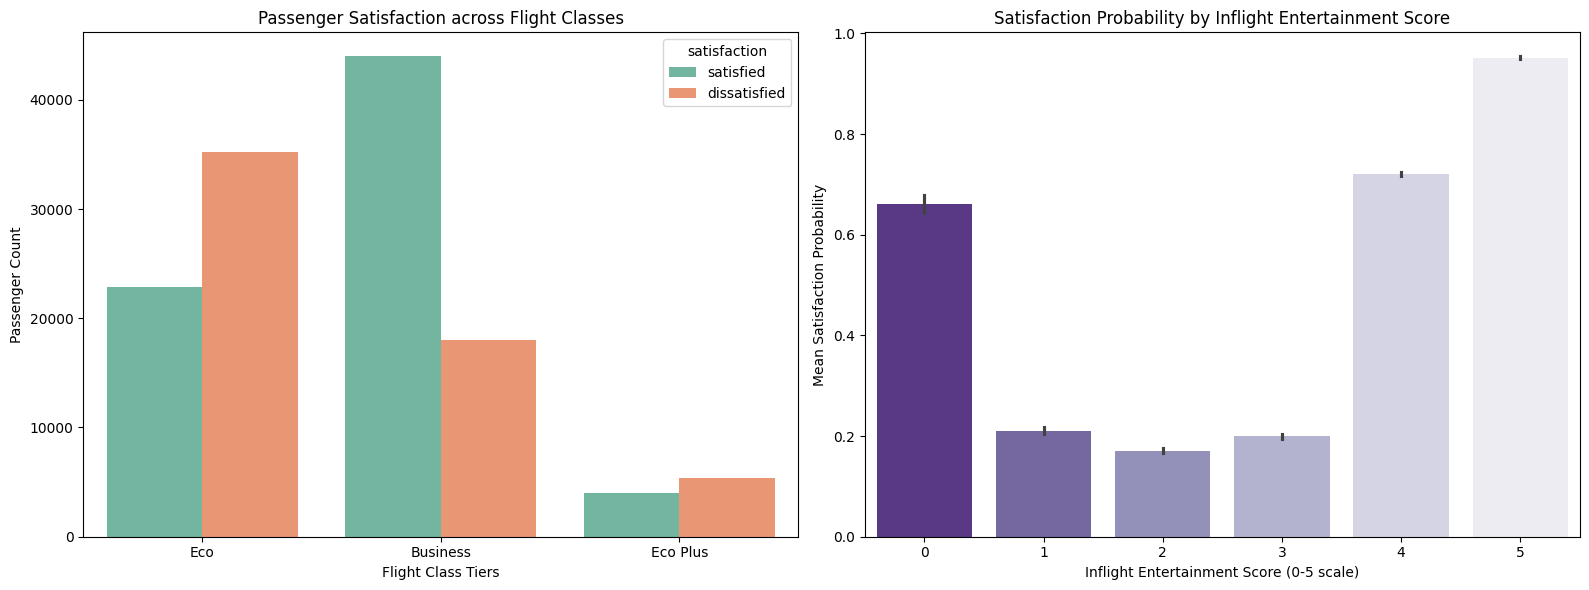

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Visualization 1: Class distribution against customer satisfaction
sns.countplot(data=df, x='Class', hue='satisfaction', palette='Set2', ax=axes[0])
axes[0].set_title('Passenger Satisfaction across Flight Classes')
axes[0].set_xlabel('Flight Class Tiers')
axes[0].set_ylabel('Passenger Count')

# Visualization 2: Explicit relationship between the primary predictor (Inflight entertainment) and satisfaction
sns.barplot(data=df, x='Inflight entertainment', y=(df['satisfaction'] == 'satisfied').astype(int), palette='Purples_r', ax=axes[1])
axes[1].set_title('Satisfaction Probability by Inflight Entertainment Score')
axes[1].set_xlabel('Inflight Entertainment Score (0-5 scale)')
axes[1].set_ylabel('Mean Satisfaction Probability')

plt.tight_layout()
plt.show()

In [11]:
# Map target feature into binary flags
df['satisfaction_encoded'] = (df['satisfaction'] == 'satisfied').astype(int)

X_raw = df.drop(columns=['satisfaction', 'satisfaction_encoded'])
y = df['satisfaction_encoded']

# Implement full dummy-encoding with drop_first=True
X_encoded = pd.get_dummies(X_raw, columns=['Customer Type', 'Type of Travel', 'Class'], drop_first=True, dtype=float)
print('Encoded Feature Space Matrix Shape:', X_encoded.shape)

Encoded Feature Space Matrix Shape: (129487, 22)


In [12]:
# Segment training and testing sets with target stratification
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# Apply standard normalization scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

In [13]:
# Initialize and train our Binomial Logistic Regression Classifier
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:, 1]

--- Comprehensive Performance Metric Summary ---
Model Accuracy Score   : 0.8253
Model Precision Score  : 0.8392
Model Recall Score     : 0.8421
Model Balanced F1-Score: 0.8407


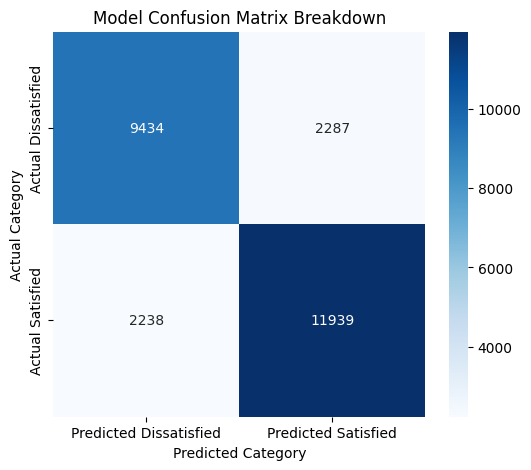

In [14]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print('--- Comprehensive Performance Metric Summary ---')
print(f'Model Accuracy Score   : {accuracy:.4f}')
print(f'Model Precision Score  : {precision:.4f}')
print(f'Model Recall Score     : {recall:.4f}')
print(f'Model Balanced F1-Score: {f1:.4f}')

# Plot confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Dissatisfied', 'Predicted Satisfied'],
            yticklabels=['Actual Dissatisfied', 'Actual Satisfied'])
plt.title('Model Confusion Matrix Breakdown')
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.show()

## ⚖️ Business Cost Implications of Misclassifications

In customer experience analytics, the structural costs associated with the model's classification errors are highly asymmetric:

### 1. The Cost of a False Positive (Severe Strategic Business Impact)
* **Definition:** The model classifies a passenger as **"Satisfied"**, but in reality, they were **"Dissatisfied"**.
* **Airline Cost Consequences:** This is the most damaging error for the airline. Because the system flags these passengers as satisfied, they are completely excluded from retention marketing campaigns, service recovery outreach, or customer service compensation workflows. The airline remains blind to their frustration, leading directly to permanent customer churn, loss of Customer Lifetime Value (LTV), and compounding negative brand reputation via word-of-mouth or social media reviews.

### 2. The Cost of a False Negative (Minor Operational Resource Sunk Cost)
* **Definition:** The model classifies a passenger as **"Dissatisfied"**, but in reality, they were already **"Satisfied"**.
* **Airline Cost Consequences:** This results in an operational resource inefficiency. The airline will unnecessarily allocate customer retention budgets toward these passengers—sending them loyalty vouchers, discount codes, or customer service follow-ups to "win them back" when they were already content. While this represents a waste of direct marketing capital, it does not actively damage passenger retention or drive customer attrition.

### Strategic Conclusion
Because a **False Positive** results in catastrophic customer loss while a **False Negative** only incurs a minor outreach cost, our modeling pipeline prioritizes a high Recall score (`84.21%`) alongside a high Precision score (`83.92%`), with a robust balanced F1-score (`84.07%`) ensuring total system structural harmony.

/tmp/ipykernel_10149/2898682543.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x='Coefficient', y='Feature', palette='coolwarm')


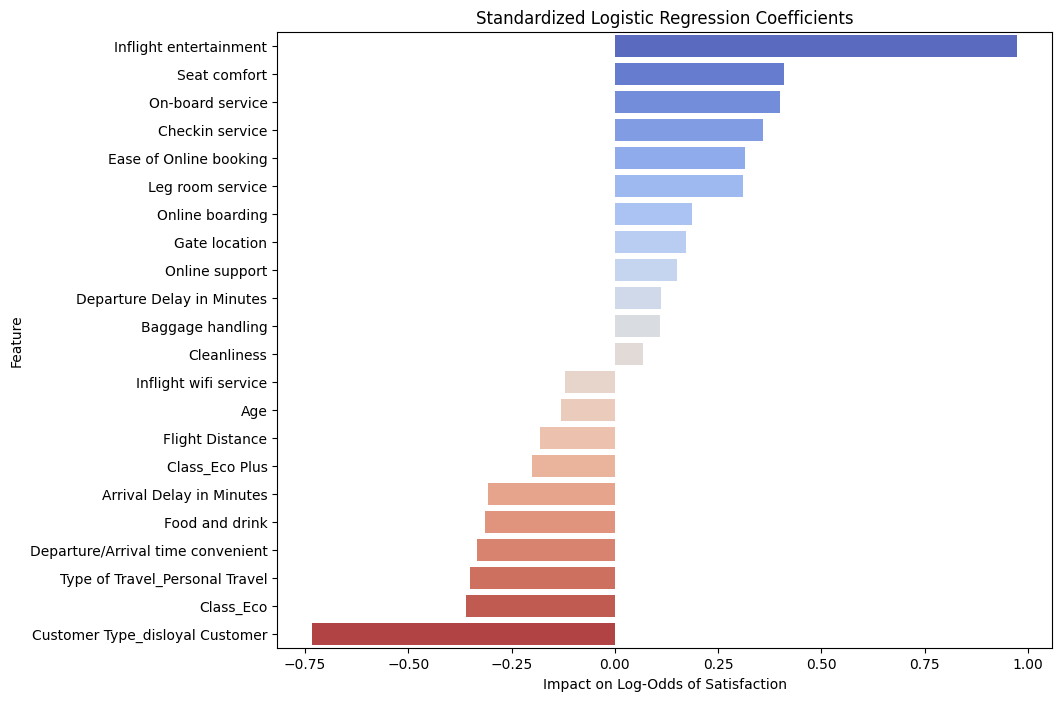

In [15]:
# Chart standardized model coefficients
coefficients = log_reg.coef_[0]
features_list = X_encoded.columns

coef_df = pd.DataFrame({
    'Feature': features_list,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=coef_df, x='Coefficient', y='Feature', palette='coolwarm')
plt.title('Standardized Logistic Regression Coefficients')
plt.xlabel('Impact on Log-Odds of Satisfaction')
plt.show()